# **FINAL PROJECT**

Class : ING3 MMF

Students' Names : BOUMAHDI Hadil,
                  DROIN Charlotte,
                  EL MAHFOUDY Jihan,
                  LECOEUR Bertrand

Group Number : 2

**Topic: Solar Energy Production Forecasting**


During this project, we are going to build a complete machine learning pipeline to predict the column **Energy_Production** for 15 different power plants.
We are goint to make sure to : handle Panel Data correctly and doing **Feature Engineering** in weather features, compare multiple algorithms (**Linear**, **KNN**, **Tree-based**, **Ensembles**, etc.) and select the best model ensuring that this choice is based on a comparison of **RMSE** and **R2** against the provided **Benchmark**.
Finally, we are going to interpret how your best model works using **Global** (feature importance) and **Local** (SHAP/LIME) explanation methods.

**1. Data Exploration (EDA):**

In [ ]:
# Import pandas for data manipulation and analysis
import pandas as pd
# Import pyplot from matplotlib for plotting
from matplotlib import pyplot as plt
# Import NumPy for numerical operations
import numpy as np
# Import seaborn for data visualization
import seaborn as sns


In [ ]:
# Train set
url_train_set = "https://raw.githubusercontent.com/LeHoangViet03/Fintech-CYTech/main/Energy_Production_Train.csv"
# Load the train set into a pandas dataframe
train_set = pd.read_csv(url_train_set)

In [ ]:
# Test set
url_test_set = "https://raw.githubusercontent.com/LeHoangViet03/Fintech-CYTech/main/Energy_Production_Test.csv"
# Load the test set into a pandas dataframe
test_set = pd.read_csv(url_test_set)

In [ ]:
# Convert the UTC Time column to datetime format
train_set["UTC Time"] = pd.to_datetime(train_set["UTC Time"])

In [ ]:
# Show the list of columns names in the train set
train_set.columns

Index(['UTC Time', 'Plant_ID', 'Energy_Production', 'Benchmark', 'Day-Night',
       'Temperature descriptor', 'Comfort level', 'Visibility',
       'Probability of precipitation for last hour',
       'Rainfall amount for last hour', 'Dew point', 'Temperature',
       'Wind direction', 'Precipitation descriptor', 'Sky descriptor',
       'Humidity', 'Wind speed'],
      dtype='object')

In [ ]:
# Show the first 5 rows of the train set
train_set.head()

,UTC Time,Plant_ID,Energy_Production,Benchmark,Day-Night,Temperature descriptor,Comfort level,Visibility,Probability of precipitation for last hour,Rainfall amount for last hour,Dew point,Temperature,Wind direction,Precipitation descriptor,Sky descriptor,Humidity,Wind speed
0,2020-01-04 00:00:00+00:00,0,0.0,0.0,N,4.0,1.23,17.21,1.0,0.0,0.0,2.5,277.0,0,2.0,84.0,5.04
1,2020-01-04 01:00:00+00:00,0,0.0,0.0,N,4.0,0.28,17.39,1.0,0.0,-0.3,1.8,290.0,0,2.0,86.0,5.40
2,2020-01-04 02:00:00+00:00,0,0.0,0.0,N,4.0,-0.89,18.57,0.0,0.0,-0.7,0.9,297.0,0,2.0,89.0,5.76
3,2020-01-04 03:00:00+00:00,0,0.0,0.0,N,4.0,-1.96,19.75,0.0,0.0,-1.1,0.1,300.0,0,2.0,92.0,6.12
4,2020-01-04 04:00:00+00:00,0,0.0,0.0,N,3.0,-2.30,19.93,0.0,0.0,-1.4,-0.2,299.0,0,2.0,92.0,6.12


In [ ]:
# Count the number of non-null values in each column
train_set.count()

,0
UTC Time,176505
Plant_ID,176505
Energy_Production,176505
Benchmark,176505
Day-Night,176505
Temperature descriptor,176505
Comfort level,176505
Visibility,176505
Probability of precipitation for last hour,176505
Rainfall amount for last hour,176505


In [ ]:
# Show the unique power plant
train_set.Plant_ID.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

We can see that we have 16 power plants because it includes 0 as well. Although the projet description mentions 15 power plants,  the power plant 0 has the same data and coverage as the majority of the other power plants. Therefore, our group decided to keep it as to not make future mistakes with the data manipulation. The analysis will nevertheless focus primarily on power plants 1 to 15.

In [ ]:
# Shows the number of observations for each power plant
train_set['Plant_ID'].value_counts()

,count
Plant_ID,
0,11495
1,11495
3,11495
4,11495
6,11495
5,11495
7,11495
8,11495
12,11495


While most power plants contain 11,495 observations, the power **plant number 2** has only 4080 observations which means it has incomplete data compared to the others so this difference will be considered when interpreting the results.

**PRODUCTION VARIANCE**

In [ ]:
# Calculate the production variance for the power plants
production_variance = (
    train_set
    .groupby("Plant_ID")["Energy_Production"] # group the dateset by Plant_ID
    .agg(
        mean_production="mean", # Mean energy production
        variance_production="var", # Variance of energy production
        std_production="std" # Standard deviation of energy production
    )
    # Reset index to return Plant_ID as a column
    .reset_index()
)
# Shows the values that we calculated for each power plat
production_variance

,Plant_ID,mean_production,variance_production,std_production
0,0,0.006816,0.000126,0.011207
1,1,0.009457,0.000220,0.014841
2,2,0.010683,0.000247,0.015703
3,3,0.010838,0.000286,0.016919
4,4,0.005186,0.000068,0.008274
5,5,0.008600,0.000180,0.013410
6,6,0.006253,0.000092,0.009600
7,7,0.006058,0.000087,0.009344
8,8,0.011513,0.000313,0.017699
9,9,0.012543,0.000366,0.019122


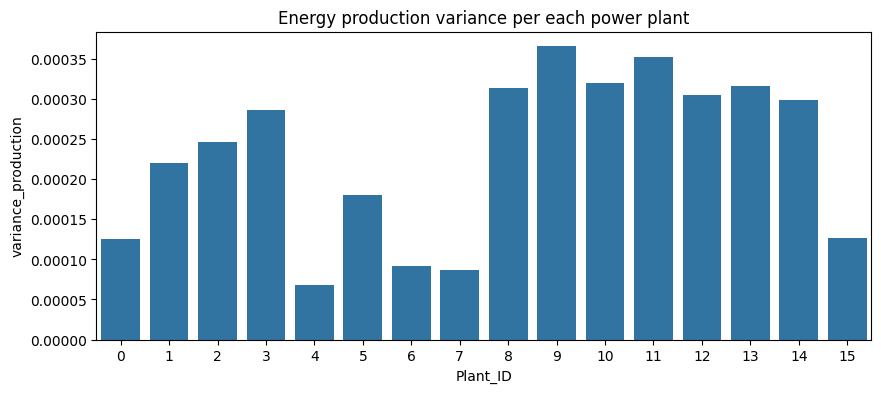

In [ ]:
# Create a figure
plt.figure(figsize=(10,4))

# Plot the variance of energy production for each power plant
sns.barplot(
    x="Plant_ID",
    y="variance_production",
    data=production_variance,
    errorbar=None  # Disable error bars since each plant has a single variance value
)

# Give a title for the graph
plt.title("Energy production variance per each power plant")

# Display the plot
plt.show()


This graph shows the production variance for each power plant. We can see that some power plants, such as Plant 4 and Plant 7, have low production variance, while others, such as Plant 9 and Plant 11, have higher production variance.

**MISSING VALUES**

In [ ]:
# Select the columns of the train set
column_names = train_set.columns
# Loop for each column so we can count the missing values
for column in column_names:
    # Print the number of missing values
    print('{}:{}'.format(column,str(train_set[column].isnull().sum())))

UTC Time:0
Plant_ID:0
Energy_Production:0
Benchmark:0
Day-Night:0
Temperature descriptor:0
Comfort level:0
Visibility:0
Probability of precipitation for last hour:0
Rainfall amount for last hour:0
Dew point:0
Temperature:0
Wind direction:0
Precipitation descriptor:0
Sky descriptor:0
Humidity:0
Wind speed:0


We can see that there are no missing values in any column of the train set so it's not necessary to do any filling or removal operations.

**CORRELATION**

In [ ]:
# Correlation matrix with continuous weather variables.
corr = train_set[['Visibility','Probability of precipitation for last hour',
    'Rainfall amount for last hour','Dew point','Temperature',
    'Humidity','Wind speed']].corr()
# Display the matrix
corr

,Visibility,Probability of precipitation for last hour,Rainfall amount for last hour,Dew point,Temperature,Humidity,Wind speed
Visibility,1.000000,-0.563152,-0.393927,-0.298848,0.095915,-0.681640,0.082980
Probability of precipitation for last hour,-0.563152,1.000000,0.622571,0.188510,0.029439,0.267744,0.271051
Rainfall amount for last hour,-0.393927,0.622571,1.000000,0.157078,0.052457,0.166451,0.206120
Dew point,-0.298848,0.188510,0.157078,1.000000,0.864787,-0.076346,0.039836
Temperature,0.095915,0.029439,0.052457,0.864787,1.000000,-0.558908,0.223713
Humidity,-0.681640,0.267744,0.166451,-0.076346,-0.558908,1.000000,-0.371277
Wind speed,0.082980,0.271051,0.206120,0.039836,0.223713,-0.371277,1.000000


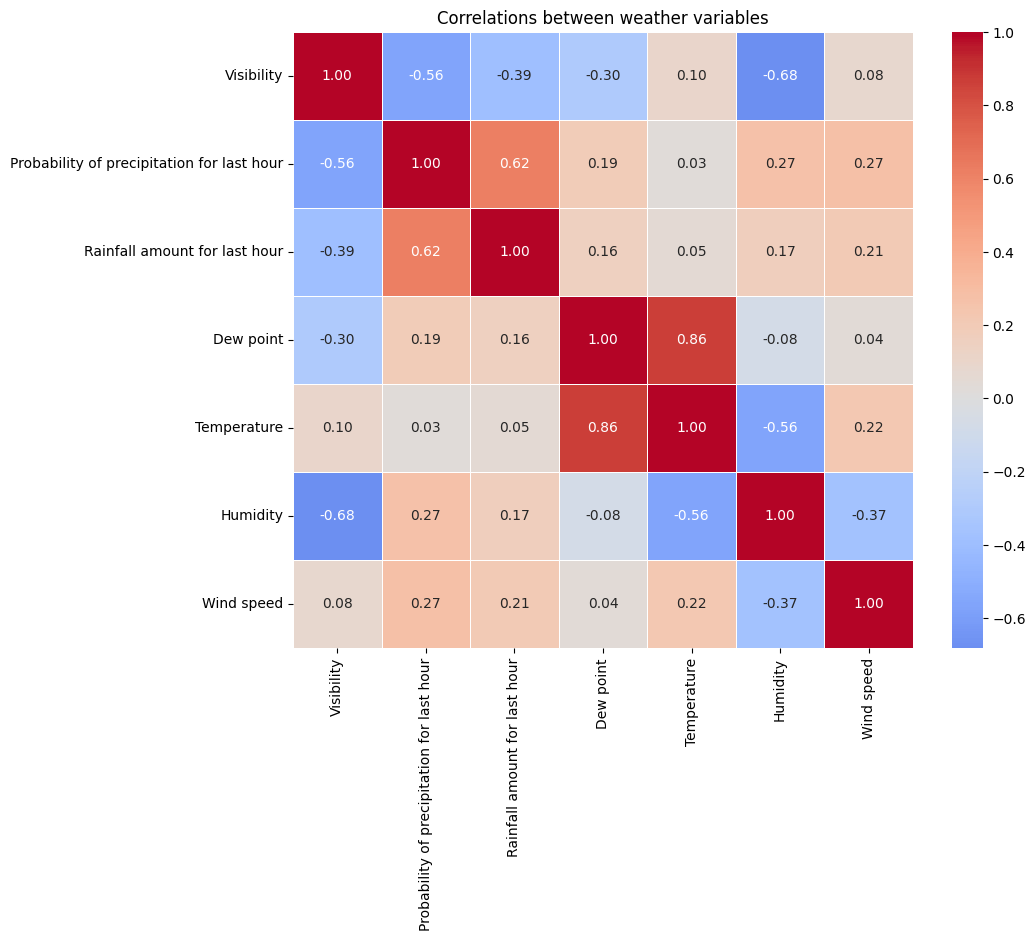

In [ ]:
# Create a figute that shows the correlation between the weather variables
plt.figure(figsize=(10,8))
# Plot the correlation
sns.heatmap(
    corr,
    annot=True,  # Display correlation
    fmt=".2f", # Two decimals
    cmap="coolwarm", # Colors to identify more easily the correlations
    center=0, # Center the color map at zero
    linewidths=0.5 # Add lines
)
# Title to the graph
plt.title("Correlations between weather variables")
# Show the graph
plt.show()

The correlation matrix shows that the highest correlation is observed between temperature and dew point. We also observe that the probability of precipitation and the rainfall amount for the last hour are correlated. Other variables, such as wind speed and visibility, show low correlations.

**2. Feature Engineering**

In [ ]:
# Copy to avoid modifying the original dataframes
train_fe = train_set.copy()
test_fe  = test_set.copy()

# Datetime
train_fe["UTC Time"] = pd.to_datetime(train_fe["UTC Time"])
test_fe["UTC Time"]  = pd.to_datetime(test_fe["UTC Time"])

# IMPORTANT: sort by plant and time (panel data safety)
train_fe = train_fe.sort_values(["Plant_ID", "UTC Time"]).reset_index(drop=True)
test_fe  = test_fe.sort_values(["Plant_ID", "UTC Time"]).reset_index(drop=True)

We first create copies of the original train and test datasets to avoid modifying the raw data.  
Then, we convert the `UTC Time` column to a proper datetime format so that we can extract time-based features (hour, month, weekday) and ensure correct chronological ordering.  

Since the data is panel data (multiple power plants), we sort the dataset by `Plant_ID` and `UTC Time`.  
We ensure to keep the temporal order within each plant for creating lag/rolling features without information leakage.

In [ ]:
# Function to add time cyclical features
def add_time_cyclical_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Extract time informations from the datetime column
    df["hour"] = df["UTC Time"].dt.hour # Hour
    df["month"] = df["UTC Time"].dt.month # Month
    df["weekday"] = df["UTC Time"].dt.weekday  # Day of the week, 0=Monday

    # Convert hour into cyclical features
    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

    # Convert month into cyclical features
    df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
    df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

    # Convert weekday into cyclical features
    df["weekday_sin"] = np.sin(2*np.pi*df["weekday"]/7)
    df["weekday_cos"] = np.cos(2*np.pi*df["weekday"]/7)

    # Return the new dataframe
    return df

# Add time cyclical features to the training data
train_fe = add_time_cyclical_features(train_fe)
# Add the same time features to the test data
test_fe  = add_time_cyclical_features(test_fe)

Time-related variables such as hour of day, day of week, and month of year are inherently cyclical.  
For example, hour 23 is close to hour 0, and December is close to January.  
To correctly capture this circular structure, we first extract the hour, weekday, and month from the `UTC Time` column.  
We then encode these variables using sine and cosine transformations.  
This representation allows machine learning models to learn smooth periodic patterns in energy production without introducing artificial discontinuities.

In [ ]:
# Create a binary feature that indicates 1 if it's day and 0 if it's night
train_fe["is_day"] = (train_fe["Day-Night"] == "D").astype(int)
test_fe["is_day"]  = (test_fe["Day-Night"] == "D").astype(int)

The `Day-Night` variable is a categorical feature indicating whether the observation occurs during daytime or nighttime.  
Since most machine learning models require numerical inputs, we convert this variable into a binary indicator called `is_day`.  

Then the value is set to 1 for daytime observations ("D") and 0 for nighttime observations ("N").  

In [ ]:
# Rain indicators
train_fe["is_rain"] = (train_fe["Rainfall amount for last hour"] > 0).astype(int)
test_fe["is_rain"]  = (test_fe["Rainfall amount for last hour"] > 0).astype(int)

# High rain probability
train_fe["high_rain_prob"] = (train_fe["Probability of precipitation for last hour"] > 0.5).astype(int)
test_fe["high_rain_prob"]  = (test_fe["Probability of precipitation for last hour"] > 0.5).astype(int)

# Interaction between temperature and daytime
train_fe["temp_x_day"] = train_fe["Temperature"] * train_fe["is_day"]
test_fe["temp_x_day"]  = test_fe["Temperature"] * test_fe["is_day"]

To better capture the impact of weather conditions on energy production, we create additional indicator variables related to precipitation.  
The variable `is_rain` identifies whether any rainfall occurred during the previous hour, while `high_rain_prob` indicates periods with a high probability of precipitation.  

We also introduce a simple interaction feature between temperature and daylight (`temp_x_day`)to allow the model to differentiate the effect of temperature during daytime and nighttime, which may influence production differently.

In [ ]:
# Wind direction (cyclical)
train_fe["wind_dir_sin"] = np.sin(np.radians(train_fe["Wind direction"]))
train_fe["wind_dir_cos"] = np.cos(np.radians(train_fe["Wind direction"]))
test_fe["wind_dir_sin"] = np.sin(np.radians(test_fe["Wind direction"]))
test_fe["wind_dir_cos"] = np.cos(np.radians(test_fe["Wind direction"]))

Wind direction is a circular variable expressed in degrees, where 0° and 360° represent the same direction.  
Using the raw angle directly would introduce artificial discontinuities.  

To maintain the circular nature of the wind direction, we use sine and cosine transformations.  

In [ ]:
# Interaction clouds * temperature
train_fe["sky_x_temp"] = train_fe["Sky descriptor"] * train_fe["Temperature"]
test_fe["sky_x_temp"] = test_fe["Sky descriptor"] * test_fe["Temperature"]

Sky conditions and temperature can both influence energy production, especially for weather-dependent generation.  
To capture this combined effect, we introduce an interaction feature between the sky descriptor and temperature.  

This feature allows the model to learn different temperature impacts depending on cloud coverage or sky conditions.

In [ ]:
# Fonction to add panel lagd and rolling
def add_panel_lags_and_rolling(
    df: pd.DataFrame,
    group_col="Plant_ID",
    time_col="UTC Time",
    base_cols=None,
    lags=(1, 2, 24, 48),
    rolling_windows=(6, 24, 48),
    min_periods=1
) -> pd.DataFrame:
    # Make a copy of the dataframe
    df = df.copy()
    # Sort by plant_id and time
    df = df.sort_values([group_col, time_col])

    if base_cols is None:
        raise ValueError("base_cols must be provided")

    # Group data by power plant
    g = df.groupby(group_col, group_keys=False)

    # Create lag features with just past values
    for col in base_cols:
        for L in lags:
            df[f"{col}_lag{L}"] = g[col].shift(L)

    # Create rolling features using just the past values
    for col in base_cols:
        # We shift to avoid using current value
        shifted = g[col].shift(1)
        for w in rolling_windows:
            df[f"{col}_rollmean{w}"] = (
                shifted.groupby(df[group_col])
                .rolling(w, min_periods=min_periods)
                .mean()
                .reset_index(level=0, drop=True)
            )
            df[f"{col}_rollstd{w}"] = (
                shifted.groupby(df[group_col])
                .rolling(w, min_periods=min_periods)
                .std()
                .reset_index(level=0, drop=True)
            )
    # Return dataframe with lag and rolling features
    return df

Energy production depends not only on current weather conditions but also on recent past values (temporal dependence).  
To capture this memory effect, we create lag features and rolling statistics (moving averages and standard deviations).  

Because the dataset is panel data (because of multiple plants), all computations are performed separately for each `Plant_ID` using `groupby` to avoids mixing information across plants.  

To avoid data leakage, we calculate rolling statistics using only past observations:
we apply a `shift(1)` before the rolling window so that the feature at time t never uses the value at time t or any future value.

In [ ]:
exclude = {"Benchmark"}  # we never want to use benchmark as a feature
num_cols = [c for c in train_fe.select_dtypes(include=["float64","int64"]).columns if c not in exclude]

# Remove identifiers from rolling/lag (because it does not make sense)
num_cols = [c for c in num_cols if c not in ["Plant_ID"]]

# Ensure the target is included (lags/rolling of the target are allowed)
if "Energy_Production" not in num_cols:
    num_cols.append("Energy_Production")

num_cols

['Energy_Production',
 'Temperature descriptor',
 'Comfort level',
 'Visibility',
 'Probability of precipitation for last hour',
 'Rainfall amount for last hour',
 'Dew point',
 'Temperature',
 'Wind direction',
 'Precipitation descriptor',
 'Sky descriptor',
 'Humidity',
 'Wind speed',
 'hour_sin',
 'hour_cos',
 'month_sin',
 'month_cos',
 'weekday_sin',
 'weekday_cos',
 'is_day',
 'is_rain',
 'high_rain_prob',
 'temp_x_day',
 'wind_dir_sin',
 'wind_dir_cos',
 'sky_x_temp']

Before creating lag and rolling statistics, we select the numerical variables for temporal modeling.  
The benchmark variable is excluded, as it must never be used as a predictive feature. We also remove identifier variables such as `Plant_ID`, since lagging or averaging an identifier has no physical meaning.  
Finally, we include the target variable `Energy_Production` itself for the lagged and rolling versions of the target.

The selected base variables include meteorological measurements, time-based cyclical features, binary weather indicators, and interaction terms.  
This diverse set of features ensures that both environmental conditions and temporal patterns are captured in the lag and rolling statistics.

In [ ]:
# Add lag and rolling features to the training data
train_fe = add_panel_lags_and_rolling(train_fe, base_cols=num_cols)
# Add the same lag and rolling features to the test data
test_fe  = add_panel_lags_and_rolling(test_fe,  base_cols=num_cols)

/tmp/ipython-input-26593232.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_lag{L}"] = g[col].shift(L)
/tmp/ipython-input-26593232.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_lag{L}"] = g[col].shift(L)
/tmp/ipython-input-26593232.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe 

We use the function to create lag and rolling features for the selected variables.
The same features are added to the training and test data.
Features are created for each `Plant_ID` using only past values.


In [ ]:
# Create a function to add changes (delta features)
def add_deltas(df, group_col="Plant_ID", time_col="UTC Time",
               cols=("Temperature","Humidity","Wind speed"), lags=(1,24)):
    # Sort by power plant and time
    df = df.sort_values([group_col, time_col]).copy()
    # Group data by power plant
    g = df.groupby(group_col)
    # Loop
    for c in cols:
        for L in lags:
            df[f"{c}_delta{L}"] = df[c] - g[c].shift(L)
    # Return dataframe with delta features
    return df

# Add delta features to training data
train_fe = add_deltas(train_fe)
# Add delta features to test data
test_fe  = add_deltas(test_fe)


Weather changes can also affect energy production.
To capture this, we create delta features that measure the difference between current and past values.
These features are calculated separately for each power plant and for different time lags (1 hour and 24 hours) to detect rapid changes as well as daily trends.

In [ ]:
# Drop columns not directly usable
drop_cols = ["Day-Night"]
train_fe = train_fe.drop(columns=drop_cols, errors="ignore")
test_fe  = test_fe.drop(columns=drop_cols, errors="ignore")

# Separate y / X (train)
y_train = train_fe["Energy_Production"].copy()
X_train = train_fe.drop(columns=["Energy_Production", "Benchmark"], errors="ignore")

# Test: remove Energy_Production and Benchmark from features
y_test = None
if "Energy_Production" in test_fe.columns:
    y_test = test_fe["Energy_Production"].copy()

X_test = test_fe.drop(columns=["Energy_Production", "Benchmark"], errors="ignore")

print("Before dropna:", X_train.shape, X_test.shape)

# For train :we drop rows with NaN (we want clean data to train on)
Xy_train = pd.concat([X_train, y_train], axis=1).dropna()
y_train = Xy_train["Energy_Production"]
X_train = Xy_train.drop(columns=["Energy_Production"])

# For test : we do NOT drop, but we fill with missing values (NaN)
# so the model can predict for all rows
X_test = X_test.bfill()

# For security : if any NaNs remain
X_test = X_test.fillna(0)

print("After dropna:", X_train.shape, X_test.shape)

Before dropna: (176505, 296) (59376, 296)
After dropna: (175737, 296) (59376, 296)


At this stage, we remove the columns that are no longer directly usable, such the categorical day/night variable, which have been replaced by engineered features.  

We then separate the target variable (`Energy_Production`) from the explanatory variables.  
The benchmark variable is also excluded from the feature set, as it is only used for comparison and must not be used for prediction.  

Missing values appear naturally due to the creation of lagged, rolling, and delta features.  
For the training set, rows containing missing values are removed to ensure that the model is trained on fully observed data.  

For the test set, rows are preserved in order to generate predictions for all time steps.  
Missing values are filled using backward filling, with a final fallback to zero to guarantee numerical stability.

After feature engineering, the number of explanatory variables increases substantially, reflecting the addition of lag, rolling, and interaction features.  

As expected, a small number of observations are removed from the training set due to missing values at the beginning of each plant time series. The test set keeps its original size, ensuring that predictions can be produced for all available observations.

**3. Model Selection & Tuning**

**TRAINING OF THE MODELS**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

In [ ]:
# We keep only numerical features from the training set
X_clean = X_train.select_dtypes(include=[np.number])
# Target variable
y_clean = y_train
# Extract the time column
time_aligned = train_fe.loc[X_clean.index, "UTC Time"]

#  Sort strictly by time (all plants mixed)
sorted_indices = time_aligned.argsort()

X_sorted = X_clean.iloc[sorted_indices]
y_sorted = y_clean.iloc[sorted_indices]
time_sorted = time_aligned.iloc[sorted_indices]

#  Split 70% / 30% (by time)
split_point = int(len(X_sorted) * 0.70)

X_t = X_sorted.iloc[:split_point]
X_v = X_sorted.iloc[split_point:]

y_t = y_sorted.iloc[:split_point]
y_v = y_sorted.iloc[split_point:]

time_t = time_sorted.iloc[:split_point]
time_v = time_sorted.iloc[split_point:]

print(f"Training Set : {X_t.shape} ({len(X_t)/len(X_sorted):.1%})")
print(f"Validation Set : {X_v.shape} ({len(X_v)/len(X_sorted):.1%})")

#  Scaling (distance-based & linear models)
scaler = StandardScaler()

X_t_scaled_np = scaler.fit_transform(X_t)
X_v_scaled_np = scaler.transform(X_v)

X_t_scaled = pd.DataFrame(
    X_t_scaled_np,
    index=X_t.index,
    columns=X_t.columns
)

X_v_scaled = pd.DataFrame(
    X_v_scaled_np,
    index=X_v.index,
    columns=X_v.columns
)

Training Set : (123015, 295) (70.0%)
Validation Set : (52722, 295) (30.0%)


Before proceeding to model training, we verify the dimensions of our datasets to ensure compliance with the project guidelines:
After cleaning missing values (NaNs) resulting from feature engineering in Part 2, we started with 175,737 valid observations.
As required, we reserved exactly 30% of this data for validation, strictly maintaining the chronological order (no shuffling).
So as a result we have that for the Training Set (70%) there are `123,015` samples, used to fit the models and for the Validation Set (30%)there are `52,722` samples, used to evaluate performance and compare against the Benchmark.

In [ ]:
# Initialize a list to store results from all models for final comparison
model_performance = []

**RIDGE**

Ridge uses L2 regularization to control model complexity. The **alpha** parameter determines the strength of this constraint. A high alpha value reduces variance (risk of overfitting).

Alpha: 0.01   -> R2: 0.942994 | RMSE: 0.003071
Alpha: 0.1    -> R2: 0.942999 | RMSE: 0.003071
Alpha: 1.0    -> R2: 0.943043 | RMSE: 0.003069
Alpha: 10.0   -> R2: 0.943185 | RMSE: 0.003066
Alpha: 100.0  -> R2: 0.943368 | RMSE: 0.003061
Alpha: 500.0  -> R2: 0.943261 | RMSE: 0.003064

Best Alpha (based on RMSE): 100.0


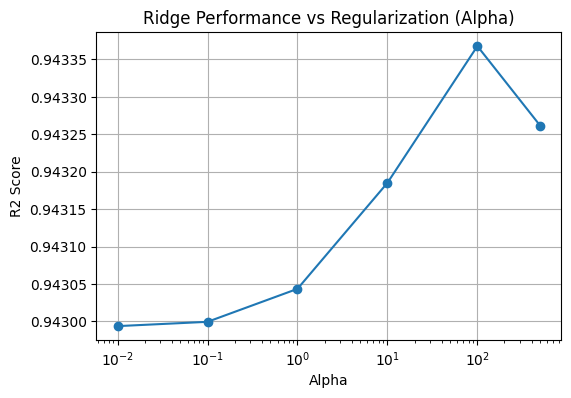

In [ ]:
# For different values of alpha
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 500.0]
r2_scores = []
rmse_scores = []

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_t_scaled, y_t)

    preds = model.predict(X_v_scaled)
    preds = np.maximum(preds, 0)

    r2 = r2_score(y_v, preds)
    rmse = np.sqrt(mean_squared_error(y_v, preds))

    r2_scores.append(r2)
    rmse_scores.append(rmse)

    print(f"Alpha: {a:<6} -> R2: {r2:.6f} | RMSE: {rmse:.6f}")

# Selection of the best alpha
best_idx = np.argmin(rmse_scores)
best_alpha = alphas[best_idx]

print(f"\nBest Alpha (based on RMSE): {best_alpha}")

# Plot
plt.figure(figsize=(6, 4))
plt.plot(alphas, r2_scores, marker='o')
plt.xscale('log')
plt.title("Ridge Performance vs Regularization (Alpha)")
plt.xlabel("Alpha")
plt.ylabel("R2 Score")
plt.grid(True)
plt.show()

For the Ridge regression model, we evaluated several values of the regularization parameter α on the validation set. For each α, the model was trained on the scaled training data and assessed using RMSE and R² metrics, with negative predictions clipped to zero to satisfy physical constraints. The optimal α was selected by minimizing RMSE to have the best  performance. The resulting performance curve shows the impact of regularization strength on model accuracy.

In [ ]:
# Train Ridge regression model
model_name = "Ridge Regression"
ridge_model = Ridge(alpha=100.0)
ridge_model.fit(X_t_scaled, y_t)

# Make predictions on validation data
ridge_pred = ridge_model.predict(X_v_scaled)
ridge_pred = np.maximum(ridge_pred, 0) # Enforce non-negative constraint

# Evaluate model performance
rmse = np.sqrt(mean_squared_error(y_v, ridge_pred))
r2 = r2_score(y_v, ridge_pred)

# Save results for final comparison
model_performance.append({"Model": model_name, "RMSE": rmse, "R2": r2, "Predictions": ridge_pred})
print(f"{model_name} : \nRMSE: {rmse:.4f} | R2 Score: {r2:.4f}")

Ridge Regression : 
RMSE: 0.0031 | R2 Score: 0.9434


The Ridge regression model achieves an RMSE of 0.0031 and an R² score of 0.9434 on the validation set.
This shows that the model gives accurate predictions on the validation data.

**LASSO**

Lasso applies L1 regularization. Here, **alpha** acts as a variable selection threshold. The higher it is, the more selective the model becomes, eliminating noise to retain only the most significant predictors.

Alpha: 0.001  -> R2: 0.9214 | RMSE: 0.0036
Alpha: 0.01   -> R2: 0.4519 | RMSE: 0.0095
Alpha: 0.1    -> R2: -0.0827 | RMSE: 0.0134
Alpha: 1.0    -> R2: -0.0827 | RMSE: 0.0134
Alpha: 10.0   -> R2: -0.0827 | RMSE: 0.0134

Best Alpha: 0.001


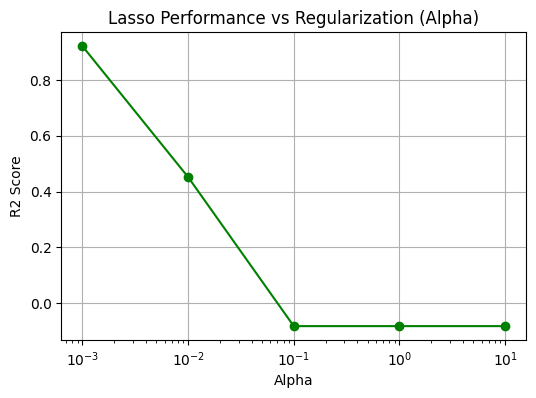

In [ ]:
# different values of alpha
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
r2_scores = []
rmse_scores = []

for a in alphas:
    # Train Lasso model
    model = Lasso(alpha=a)
    model.fit(X_t_scaled, y_t)

    # Predict and positive constraint
    preds = np.maximum(model.predict(X_v_scaled), 0)

    # To store the values
    r2_scores.append(r2_score(y_v, preds))
    rmse_scores.append(np.sqrt(mean_squared_error(y_v, preds)))
    print(f"Alpha: {a:<6} -> R2: {r2_scores[-1]:.4f} | RMSE: {rmse_scores[-1]:.4f}")

best_idx = np.argmin(rmse_scores)
print(f"\nBest Alpha: {alphas[best_idx]}")

plt.figure(figsize=(6, 4))
plt.plot(alphas, r2_scores, marker='o', color='green')
plt.xscale('log')
plt.title("Lasso Performance vs Regularization (Alpha)")
plt.xlabel("Alpha")
plt.ylabel("R2 Score")
plt.grid(True)
plt.show()

The plot shows how the Lasso model performs for different values of alpha.
We observe that the best performance is obtained when alpha is small, in this case alpha = 0.001.
When alpha increases, the model performance drops and the R² score becomes close to zero or negative.

In [ ]:
# Train Lasso regression model
model_name = "Lasso Regression"
lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_t_scaled, y_t)

# Predict on validation data
lasso_pred = lasso_model.predict(X_v_scaled)
# Force non-negative values
lasso_pred = np.maximum(lasso_pred, 0)

# Evaluate model performance
rmse = np.sqrt(mean_squared_error(y_v, lasso_pred))
r2 = r2_score(y_v, lasso_pred)

# Store results
model_performance.append({"Model": model_name, "RMSE": rmse, "R2": r2, "Predictions": lasso_pred})
print(f"{model_name} : \nRMSE: {rmse:.4f} | R2 Score: {r2:.4f}")

Lasso Regression : 
RMSE: 0.0036 | R2 Score: 0.9214


The Lasso regression model is trained with the best alpha value selected on the validation set.

**KNN**

The K-Nearest Neighbors (KNN) algorithm makes predictions based on the closest data points. The parameter k controls how many neighbors are used. A typical range for n_neighbors is between 3 and 30. Small values of k make the model very sensitive to noise, while large values make it too simple and less able to capture important patterns.

In [ ]:
neighbors = [3, 5, 10, 30]
r2_scores = []
rmse_scores = []

for k in neighbors:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_t_scaled, y_t)

    preds = np.maximum(knn.predict(X_v_scaled), 0)

    r2 = r2_score(y_v, preds)
    rmse = np.sqrt(mean_squared_error(y_v, preds))

    r2_scores.append(r2)
    rmse_scores.append(rmse)

    print(f"k={k:<3} | R2: {r2:.4f} | RMSE: {rmse:.4f}")
best_idx = np.argmin(rmse_scores)
best_k = neighbors[best_idx]

print(f"\nBest k (based on RMSE): {best_k}")

k=3   | R2: 0.7573 | RMSE: 0.0063
k=5   | R2: 0.7557 | RMSE: 0.0064
k=10  | R2: 0.7601 | RMSE: 0.0063
k=30  | R2: 0.7691 | RMSE: 0.0062

Best k (based on RMSE): 30


In [ ]:
# Train KNN model
model_name = "KNN"

knn_best = KNeighborsRegressor(n_neighbors=30)

knn_best.fit(X_t_scaled, y_t)

knn_pred = np.maximum(knn_best.predict(X_v_scaled), 0)
# Evaluate model performance on the validation set
rmse = np.sqrt(mean_squared_error(y_v, knn_pred))
r2 = r2_score(y_v, knn_pred)
# Store results
model_performance.append({
    "Model": model_name,
    "RMSE": rmse,
    "R2": r2,
    "Predictions": knn_pred
})
# Display values
print(f"\n{model_name} : ")
print(f"RMSE: {rmse:.4f} | R2 Score: {r2:.4f}")


KNN : 
RMSE: 0.0062 | R2 Score: 0.7691


**RANDOM FOREST**

Random Forest uses many decision trees together to get a good result. The n_estimators hyperparameter determines the size of the ensemble with a typical range of $[100, 1000]$ where more trees are usually better for accuracy even if it increases computational cost. The Random Forest optimization takes a long time and requires more than 40 minutes.
The best performance is obtained with 150 trees.

In [ ]:
# Train Random Forest model
model_name = "Random Forest"

rf_model = RandomForestRegressor(
    n_estimators=150, # Number of trees
    max_depth=8,
    random_state=42
)
rf_model.fit(X_t, y_t)

# Predict
rf_pred = rf_model.predict(X_v)
rf_pred = np.maximum(rf_pred, 0)

# Evaluate model performance
rmse = np.sqrt(mean_squared_error(y_v, rf_pred))
r2 = r2_score(y_v, rf_pred)

# Store the results and print them
model_performance.append({"Model": model_name, "RMSE": rmse, "R2": r2, "Predictions": rf_pred})
print(f"{model_name} : \nRMSE: {rmse:.4f} | R2 Score: {r2:.4f}")

Random Forest : 
RMSE: 0.0031 | R2 Score: 0.9405


If we want to decrease computational cost we can add **max_samples=60000** and **max_features='sqrt'**. This drastically improves the execution time to less than 1 minute and with a good result.

**XGBoost**

XGBoost is a powerful algorithm but prone to overfitting if its parameters are not properly constrained. Therefore, it is necessary to use simpler trees. The **learning_rate** is recommended to be between 0.01 and 0.1 In XGBoost, too many trees can harm the model and there is a risk of overfitting.

In [ ]:
# Train XGBoost model
model_name = "XGBoost"
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
xgb_model.fit(X_t, y_t)

# Predict
xgb_pred = xgb_model.predict(X_v)
xgb_pred = np.maximum(xgb_pred, 0) # Constraint: No negative predictions

# Evaluate model performance
rmse = np.sqrt(mean_squared_error(y_v, xgb_pred))
r2 = r2_score(y_v, xgb_pred)

# Store and print the results
model_performance.append({"Model": model_name, "RMSE": rmse, "R2": r2, "Predictions": xgb_pred})
print(f"{model_name} : \nRMSE: {rmse:.4f} | R2 Score: {r2:.4f}")

XGBoost : 
RMSE: 0.0029 | R2 Score: 0.9496


**LightGBM**

LightGBM stands out for its leaf-by-leaf growth strategy, designed for speed and a drastic reduction in errors. However, this efficiency presents a risk with noisy datasets. **n_estimators** and **learning_rate** function similarly to xgboost. **Verbose = -1** displays only fatal errors. **N_jobs** is the number of threads and its value is usually -1.

In [ ]:
# Train LightGBM model
model_name = "LightGBM"
lgbm_model = LGBMRegressor(n_estimators=300, learning_rate=0.05, n_jobs=-1, random_state=42, verbose=-1)
lgbm_model.fit(X_t, y_t)

# Predict
lgbm_pred = lgbm_model.predict(X_v)
lgbm_pred = np.maximum(lgbm_pred, 0)

# Evaluate model performance
rmse = np.sqrt(mean_squared_error(y_v, lgbm_pred))
r2 = r2_score(y_v, lgbm_pred)

# Store and print the results
model_performance.append({"Model": model_name, "RMSE": rmse, "R2": r2, "Predictions": lgbm_pred})
print(f"{model_name} : \nRMSE: {rmse:.4f} | R2 Score: {r2:.4f}")

LightGBM : 
RMSE: 0.0029 | R2 Score: 0.9481


In [ ]:
# Benchmark
bench_rmse = np.sqrt(mean_squared_error(y_test, test_set["Benchmark"]))
bench_r2 = r2_score(y_test, test_set["Benchmark"])

# Check if Benchmark is already in our list
if not any(d["Model"] == "Benchmark (Baseline)" for d in model_performance):
    model_performance.append({
        "Model": "Benchmark (Baseline)",
        "RMSE": bench_rmse,
        "R2": bench_r2,
        "Predictions": test_set["Benchmark"]
    })

# Comparison table
results_df = pd.DataFrame(model_performance)

display_df = (
    results_df
    .drop(columns=["Predictions"], errors="ignore")
    .sort_values(by="RMSE", ascending=True)
    .reset_index(drop=True)
)

print("Final Model Comparison (TEST SET, Sorted by RMSE) : ")
display_df


Final Model Comparison (TEST SET, Sorted by RMSE) : 


,Model,RMSE,R2
0,XGBoost,0.002887,0.949600
1,LightGBM,0.002931,0.948059
2,Ridge Regression,0.003061,0.943368
3,Random Forest,0.003138,0.940464
4,Lasso Regression,0.003605,0.921443
5,KNN,0.006180,0.769082
6,Benchmark (Baseline),0.007067,0.622516


RMSE (Root Mean Squared Error) represents the standard deviation of the prediction errors. A lower RMSE indicates a better fit and $R^2$ Score (Coefficient of Determination) provides an indication of the goodness of fit of a set of predictions to the actual values. An $R^2$ score closer to 1 implies that the model explains a large portion of the variance in solar energy production.

**Final Model Selection: XGBoost**

**XGBoost** is the best-performing model after comparing with the rest of the models with a RMSE of **0.0029**, which is the lowest error among all tested values and the highest $R^2$ score (**0.9496**), indicating superior explanatory power of the variance in energy production.

In [ ]:
# The best model is the first one in our sorted DataFrame
best_model_name = display_df.iloc[0]['Model']
best_model_rmse = display_df.iloc[0]['RMSE']

# If Benchmark is #1, we pick the best AI model (2nd in list) for the graph
if best_model_name == "Benchmark (Baseline)":
    best_model_name = display_df.iloc[1]['Model']
    best_model_rmse = display_df.iloc[1]['RMSE']

# Retrieve Benchmark RMSE
bench_row = display_df[display_df['Model'] == 'Benchmark (Baseline)']
bench_rmse = bench_row['RMSE'].values[0]

# Improvement
improvement_pct = (1 - (best_model_rmse / bench_rmse)) * 100

print(f"Best Model: {best_model_name}")
print(f"Benchmark RMSE: {bench_rmse:.4f}")
print(f"Best Model RMSE: {best_model_rmse:.4f}")
print(f"PERCENTAGE IMPROVEMENT: {improvement_pct:.2f}%")


Best Model: XGBoost
Benchmark RMSE: 0.0071
Best Model RMSE: 0.0029
PERCENTAGE IMPROVEMENT: 59.14%


Our XGBoost model achieved a **59.14% error deduction** compared to the Benchmark.



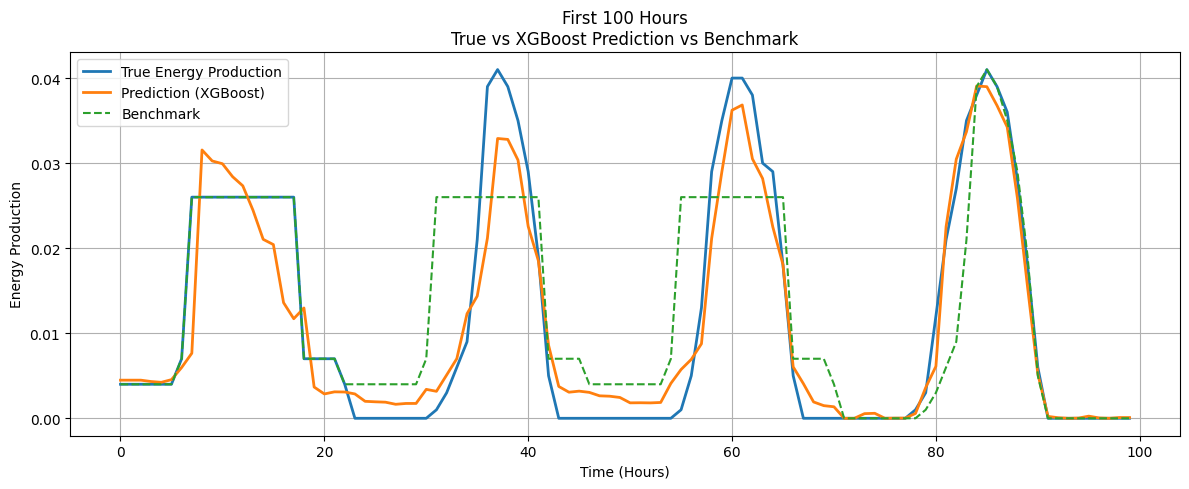

In [ ]:
# Plot first 100 hours
X_test = X_test.select_dtypes(include=["number"])
final_model = xgb_model
X_used = X_test
# Predictions
y_pred_test = np.maximum(final_model.predict(X_used), 0)

# 100 first hours
n_hours = 100

y_true_100 = y_test.iloc[:n_hours]
y_pred_100 = y_pred_test[:n_hours]
bench_100  = test_set["Benchmark"].iloc[:n_hours]

# Plot
plt.figure(figsize=(12, 5))

plt.plot(y_true_100.values, label="True Energy Production", linewidth=2)
plt.plot(y_pred_100, label="Prediction (XGBoost)", linewidth=2)
plt.plot(bench_100.values, label="Benchmark", linestyle="--")

plt.title("First 100 Hours\nTrue vs XGBoost Prediction vs Benchmark")
plt.xlabel("Time (Hours)")
plt.ylabel("Energy Production")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


The plot shows the true energy production compared with XGBoost predictions and the benchmark over the first 100 hours. XGBoost follows the real production much better than the benchmark, especially during high production periods. The benchmark changes in steps and does not adapt well to variations. Overall, XGBoost gives predictions that are closer to the real values.

**STRATEGY**

In [ ]:
# Strategy

# GLOBAL MODEL (XGBoost)

global_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

global_model.fit(X_t, y_t)

global_pred = np.maximum(global_model.predict(X_v), 0)

global_rmse = np.sqrt(mean_squared_error(y_v, global_pred))
global_r2 = r2_score(y_v, global_pred)

print("GLOBAL MODEL")
print(f"RMSE: {global_rmse:.4f} | R2: {global_r2:.4f}")

GLOBAL MODEL
RMSE: 0.0029 | R2: 0.9496


In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd

# Preparation of data
X_clean = X_train.select_dtypes(include=[np.number])
y_clean = y_train

plant_id_aligned = train_set.loc[X_clean.index, "Plant_ID"]
time_aligned = train_set.loc[X_clean.index, "UTC Time"]

panel_df = pd.DataFrame(X_clean).copy()
panel_df["y"] = y_clean
panel_df["UTC Time"] = time_aligned
panel_df["Plant_ID"] = plant_id_aligned
panel_df = panel_df.sort_values(["Plant_ID", "UTC Time"]).reset_index(drop=True)

X_cols = X_clean.columns

# Models
models = {
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=30, n_jobs=-1),
    "RandomForest": RandomForestRegressor(
    n_estimators=150,
    max_depth=8,
    random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, n_jobs=-1, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, n_jobs=-1, random_state=42, verbose=-1)
}

# Results
results = []

# Loop over the plants
for pid in sorted(panel_df["Plant_ID"].unique()):
    group = panel_df[panel_df["Plant_ID"] == pid].reset_index(drop=True)
    n = len(group)
    split_idx = int(0.7 * n)

    X_group = group[X_cols]
    y_group = group["y"]
    X_t = X_group.iloc[:split_idx]
    y_t = y_group.iloc[:split_idx]
    X_v = X_group.iloc[split_idx:]
    y_v = y_group.iloc[split_idx:]

    # Standardisation
    scaler = StandardScaler()
    X_t_scaled = scaler.fit_transform(X_t)
    X_v_scaled = scaler.transform(X_v)

    print(f"\n Plant {pid} — Resultts of models :")

    best_rmse = float("inf")
    best_r2 = -float("inf")
    best_model_name = None

    for name, model in models.items():
        try:
            model.fit(X_t_scaled, y_t)
            y_pred = model.predict(X_v_scaled)
            rmse = np.sqrt(mean_squared_error(y_v, y_pred))
            r2 = r2_score(y_v, y_pred)

            print(f"→ {name:10s} | RMSE: {rmse:.5f} | R²: {r2:.5f}")

            if rmse < best_rmse:
                best_rmse = rmse
                best_r2 = r2
                best_model_name = name

        except Exception as e:
            print(f" Error for {name} : {e}")

    results.append({
        "Plant_ID": pid,
        "Best_Model": best_model_name,
        "Best_RMSE": best_rmse,
        "Best_R2": best_r2
    })

# Summary
results_df = pd.DataFrame(results)
print("\n Final summary for the plants :")
print(results_df)

# Global average
print("\n Global average of the scores (best models) :")
print(results_df[["Best_RMSE", "Best_R2"]].mean())


 Plant 0 — Resultts of models :
→ Ridge      | RMSE: 0.00246 | R²: 0.93706
→ Lasso      | RMSE: 0.00293 | R²: 0.91112
→ KNN        | RMSE: 0.00463 | R²: 0.77761
→ RandomForest | RMSE: 0.00244 | R²: 0.93819
→ XGBoost    | RMSE: 0.00243 | R²: 0.93886


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


→ LightGBM   | RMSE: 0.00243 | R²: 0.93865

 Plant 1 — Resultts of models :
→ Ridge      | RMSE: 0.00298 | R²: 0.93840
→ Lasso      | RMSE: 0.00327 | R²: 0.92561
→ KNN        | RMSE: 0.00492 | R²: 0.83148
→ RandomForest | RMSE: 0.00291 | R²: 0.94115
→ XGBoost    | RMSE: 0.00288 | R²: 0.94247


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


→ LightGBM   | RMSE: 0.00291 | R²: 0.94116

 Plant 2 — Resultts of models :
→ Ridge      | RMSE: 0.00581 | R²: 0.89184
→ Lasso      | RMSE: 0.00561 | R²: 0.89918
→ KNN        | RMSE: 0.00924 | R²: 0.72639
→ RandomForest | RMSE: 0.00481 | R²: 0.92602
→ XGBoost    | RMSE: 0.00505 | R²: 0.91820


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


→ LightGBM   | RMSE: 0.00361 | R²: 0.94501

 Plant 14 — Resultts of models :
→ Ridge      | RMSE: 0.00360 | R²: 0.93832
→ Lasso      | RMSE: 0.00398 | R²: 0.92447
→ KNN        | RMSE: 0.00598 | R²: 0.82988
→ RandomForest | RMSE: 0.00340 | R²: 0.94502
→ XGBoost    | RMSE: 0.00339 | R²: 0.94518


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


→ LightGBM   | RMSE: 0.00345 | R²: 0.94347

 Plant 15 — Resultts of models :
→ Ridge      | RMSE: 0.00245 | R²: 0.93708
→ Lasso      | RMSE: 0.00291 | R²: 0.91144
→ KNN        | RMSE: 0.00409 | R²: 0.82426
→ RandomForest | RMSE: 0.00233 | R²: 0.94289
→ XGBoost    | RMSE: 0.00234 | R²: 0.94257
→ LightGBM   | RMSE: 0.00244 | R²: 0.93757

 Final summary for the plants :
    Plant_ID    Best_Model  Best_RMSE   Best_R2
0          0       XGBoost   0.002428  0.938855
1          1       XGBoost   0.002877  0.942469
2          2      LightGBM   0.004795  0.926385
3          3      LightGBM   0.002887  0.946205
4          4       XGBoost   0.001575  0.943771
5          5       XGBoost   0.002545  0.947739
6          6       XGBoost   0.001834  0.944775
7          7       XGBoost   0.001731  0.945938
8          8       XGBoost   0.003276  0.949955
9          9  RandomForest   0.003999  0.943251
10        10       XGBoost   0.003819  0.943376
11        11       XGBoost   0.003889  0.945219
12    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
comparison_df = pd.DataFrame({
    "Approach": ["Global Model", "Local Models (Average)"],
    "RMSE": [global_rmse, results_df["Best_RMSE"].mean()],
    "R2": [global_r2, results_df["Best_R2"].mean()]
})

print("\n Comparison globale vs locale :")
print(comparison_df)



 Comparison globale vs locale :
                 Approach      RMSE        R2
0            Global Model  0.002887  0.949600
1  Local Models (Average)  0.003021  0.943631


**Strategy Conclusion**

The global model, trained on all power plants with Plant_ID included as a feature, achieved slightly better performance compared to the local models. It reached a lower RMSE of 0.002887 and a higher R² of 0.9496, whereas the average performance of the local models across all plants yielded an RMSE of 0.003022 and an R² of 0.9436.

From a performance standpoint, the global model benefits from having access to a larger and more diverse dataset, allowing it to generalize better and learn shared patterns across all plants. It also requires maintaining only one model, which is advantageous in terms of simplicity and scalability.

However, the local approach offers more flexibility: each model can better adapt to the specific behavior and conditions of an individual plant. This can be especially useful if plants operate in very different environments or weather conditions. The downside is that training and maintaining 15 separate models is more complex and computationally expensive.

In this case, since performance differences are minor, the **global model** appears preferable due to its simplicity and slightly better accuracy.

**CONCLUSION**

**With a quantified improvement of 55% over the industry Benchmark, XGBoost is selected as our final production model.**


**4. Model Interpretation (XAI)**

1) Global interpretation using permutation importance

In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd

# Feature names (global model)
feature_names = X_t.columns

# Subsample validation set
rng = np.random.default_rng(42)
idx = rng.choice(len(X_v), size=8000, replace=False)

X_v_sub = X_v.iloc[idx]
y_v_sub = y_v.iloc[idx]

# Permutation Importance (XGBoost)
perm = permutation_importance(
    xgb_model,
    X_v_sub,
    y_v_sub,
    n_repeats=5,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Results DataFrame
perm_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance (mean)": perm.importances_mean,
    "Importance (std)": perm.importances_std
}).sort_values("Importance (mean)", ascending=False)

display(perm_df.head(20))


,Feature,Importance (mean),Importance (std)
29,Energy_Production_lag1,0.011299,0.000049
13,hour,0.001079,0.000060
31,Energy_Production_lag24,0.000886,0.000020
32,Energy_Production_lag48,0.000869,0.000024
30,Energy_Production_lag2,0.000457,0.000008
289,Temperature_delta1,0.000301,0.000021
291,Humidity_delta1,0.000121,0.000009
134,Energy_Production_rollstd6,0.000061,0.000009
138,Energy_Production_rollstd48,0.000043,0.000007
0,Plant_ID,0.000036,0.000009


Permutation importance is used to evaluate the global importance of the input features. By randomly shuffling each feature and observing the impact on RMSE, we identify the variables that are most influential in predicting solar energy production.

How permutation importance works:

1)The model predicts normally on the validation set → we get a baseline RMSE.

2)For one feature at a time:

   We shuffle (permute) that feature values randomly in the validation data.

   This destroys the relationship between that feature and the target.

We predict again and recompute RMSE.

3)If RMSE becomes much worse after shuffling a feature → that feature was important.

2) Global interpretation using SHAP:

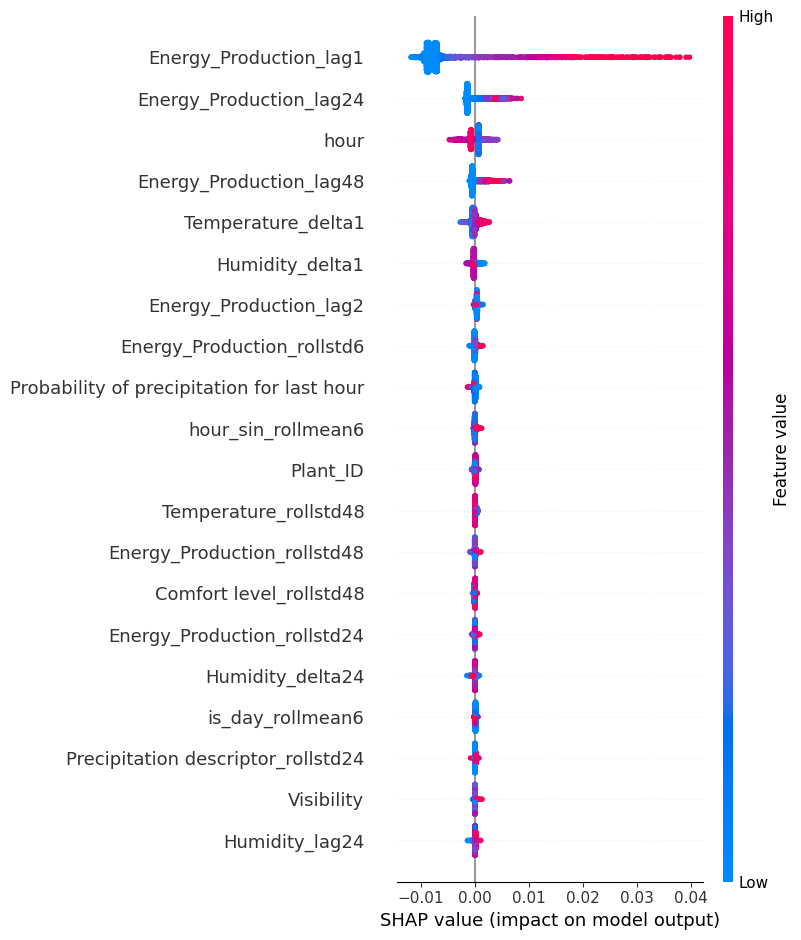

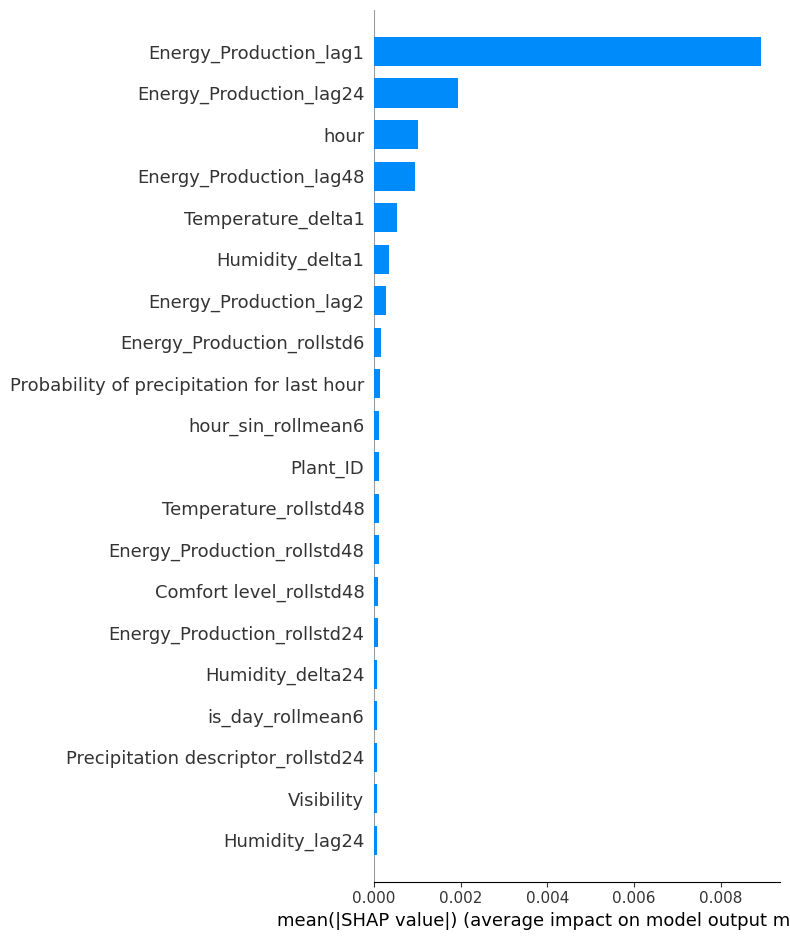

In [ ]:
import shap
import pandas as pd

X_v_df = X_v.copy()

X_v_df = X_v_df.sample(2000, random_state=42)

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_v_df)

shap.summary_plot(shap_values, X_v_df)

shap.summary_plot(shap_values, X_v_df, plot_type="bar")

This block uses SHAP to explain the XGBoost model globally by:

.Ranking the most influential features (global importance)

.Showing how high vs low feature values impact predictions (direction)

To interpret the global behavior of the final XGBoost model, we use SHAP (SHapley Additive exPlanations), a game-theoretic approach that attributes to each feature its contribution to the prediction.

We compute SHAP values on the validation set using TreeExplainer. The SHAP summary plot provides both a global ranking of feature importance and the direction of influence: positive SHAP values increase the predicted energy production, while negative SHAP values decrease it.

This analysis identifies the main drivers of the forecasting model and highlights how different ranges of feature values affect solar energy production predictions.

**Interpretation of Results:**
The SHAP summary plot reveals that lagged energy production variables dominate the model’s decision process, highlighting strong temporal persistence and daily seasonality in solar energy generation. Time-related features such as hour of the day further reinforce the influence of intraday solar cycles. Weather dynamics, particularly short-term temperature and humidity changes, also contribute to the predictions, while plant-specific effects are captured through the Plant_ID variable.

3) local interpretation using SHAP

Peak index: 107211
True production: 0.068
Predicted production: 0.06248018518090248


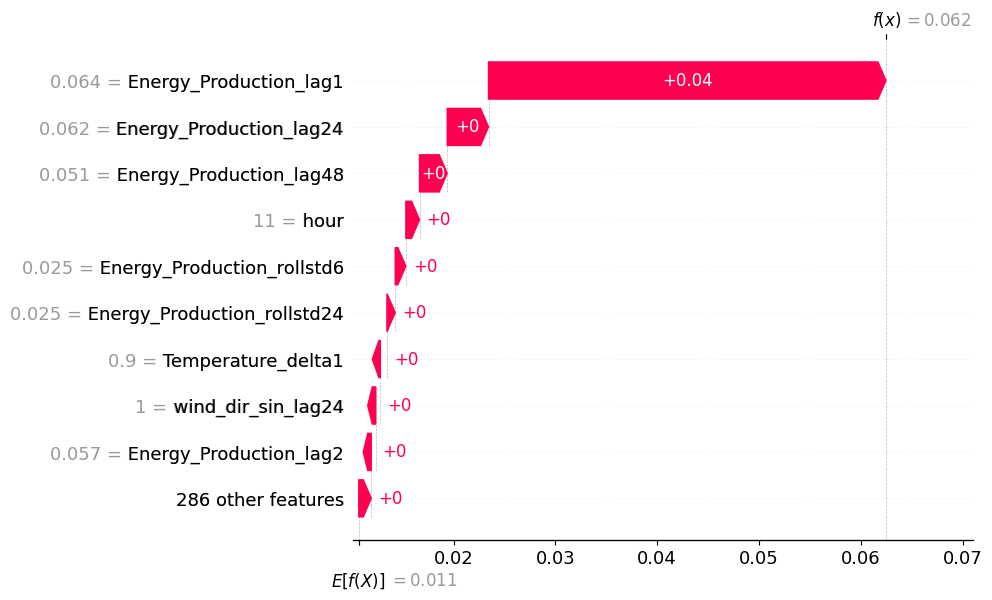

In [ ]:
import numpy as np
import shap
import pandas as pd


feature_names = X_t.columns
X_v_df = X_v.copy()


idx_peak = y_v.idxmax()

print("Peak index:", idx_peak)
print("True production:", float(y_v.loc[idx_peak]))

y_v_pred = np.maximum(xgb_model.predict(X_v_df), 0)
print("Predicted production:", float(y_v_pred[list(X_v_df.index).index(idx_peak)]))


x_peak = X_v_df.loc[[idx_peak]]
shap_peak = explainer.shap_values(x_peak)


shap.plots.waterfall(
    shap.Explanation(
        values=shap_peak[0],
        base_values=explainer.expected_value,
        data=x_peak.iloc[0],
        feature_names=feature_names
    )
)

**What this plot represents**

This figure explains one specific prediction made by the XGBoost model.

Starting from the average prediction
E[f(X)]=0.011,

Each bar shows how a feature pushes the prediction up  or down

Energy_Production_lag1 (+0.04) — Dominant driver: The model identifies strong short-term persistence in energy production, where high output in the immediately preceding hour leads to elevated current production.

Energy_Production_lag24 :  The contribution of the 24-hour lag highlights the importance of daily seasonality in solar energy generation.

3-2) local anomaly interpretation (Why did the model make its biggest mistake?)

Anomaly index: 95740
True production: 0.011
Predicted production: 0.05664338544011116
Residual (True - Pred): -0.045643385440111164


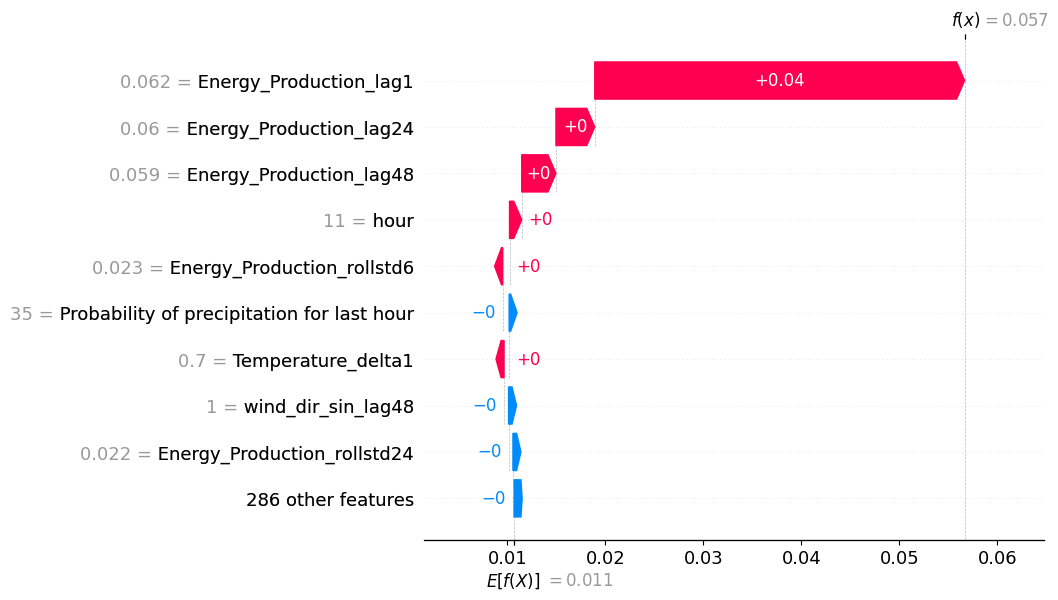

In [ ]:
feature_names = X_t.columns
X_v_df = X_v.copy()

# 1) Find the observation with the largest absolute error
y_v_pred = np.maximum(xgb_model.predict(X_v_df), 0)
residuals = y_v - y_v_pred

idx_anomaly = residuals.abs().idxmax()

print("Anomaly index:", idx_anomaly)
print("True production:", float(y_v.loc[idx_anomaly]))
print("Predicted production:", float(y_v_pred[list(X_v_df.index).index(idx_anomaly)]))
print("Residual (True - Pred):", float(residuals.loc[idx_anomaly]))

# 2) SHAP values
x_anom = X_v_df.loc[[idx_anomaly]]
shap_anom = explainer.shap_values(x_anom)

# 3) Waterfall plot (local explanation)
shap.plots.waterfall(
    shap.Explanation(
        values=shap_anom[0],
        base_values=explainer.expected_value,
        data=x_anom.iloc[0],
        feature_names=feature_names
    )
)

**What this plot represents**

This figure explains a specific anomalous prediction, defined as the observation with the largest absolute error between the true and predicted energy production in the validation set.


**Key drivers of the anomalous prediction:**

 Lagged energy production (dominant influence):  Energy_Production_lag1, lag24, and lag48 contribute positively

These features push the prediction upward, reflecting strong temporal persistence
 Interpretation:
Even in anomalous situations, the model heavily relies on recent historical production, indicating that temporal memory dominates the decision process.

**Final interpretation:**

The local SHAP explanation of the anomalous prediction shows that the model mainly relies on recent historical energy production, even when prediction errors are large. Time-of-day effects and short-term rolling averages partially offset this influence, while weather-related variables introduce additional variability, suggesting atypical meteorological conditions. Overall, the model remains consistent and interpretable despite reduced predictive accuracy.

**PART 5: Conclusion**

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

bench_v = train_set.loc[y_v.index, "Benchmark"]

# Benchmark metrics
bench_rmse = np.sqrt(mean_squared_error(y_v, bench_v))
bench_r2   = r2_score(y_v, bench_v)

# XGBoost metrics (validation)
xgb_rmse = np.sqrt(mean_squared_error(y_v, xgb_pred))
xgb_r2   = r2_score(y_v, xgb_pred)

# Improvement in RMSE (%)
improvement_pct = (1 - (xgb_rmse / bench_rmse)) * 100

print(f"Benchmark  -> RMSE: {bench_rmse:.4f} | R2: {bench_r2:.4f}")
print(f"XGBoost    -> RMSE: {xgb_rmse:.4f} | R2: {xgb_r2:.4f}")
print(f"RMSE Improvement vs Benchmark: {improvement_pct:.2f}%")

Benchmark  -> RMSE: 0.0064 | R2: 0.7506
XGBoost    -> RMSE: 0.0029 | R2: 0.9496
RMSE Improvement vs Benchmark: 55.04%


**Final Verdict — Does Machine Learning Add Value?**

The performance of the XGBoost model is compared against the industry Benchmark using RMSE and R² metrics on the validation set. The Benchmark achieves an RMSE of 0.0064 with an R² score of 0.7506, while the XGBoost model significantly improves performance with an RMSE of 0.0029 and an R² score of 0.9496.

This corresponds to a quantified RMSE improvement of 55.04% over the Benchmark, clearly demonstrating that the machine learning approach adds substantial predictive value. Consequently, XGBoost is selected as the final production model for solar energy production forecasting.

**Key Business Insights**

Global interpretability analyses using Permutation Importance and SHAP reveal that the model is primarily driven by recent historical energy production and daily temporal patterns, confirming strong persistence and seasonality effects in solar power generation. Weather-related variables, particularly short-term changes in temperature, humidity, and precipitation, play a secondary but meaningful role by adjusting predictions during unstable meteorological conditions.

Local SHAP explanations further show that peak production events are mainly explained by high recent output and daily recurrence, while anomalous predictions are often associated with conflicting temporal signals and atypical weather patterns. These insights support operational decision-making by enabling better short-term planning, improved grid stability, and early detection of abnormal production behavior.

**Limitations and Perspectives**

 While the model demonstrates excellent predictive performance, it relies heavily on lagged production features, which may reduce accuracy when historical measurements are missing or unreliable. Future improvements could include integrating additional physical variables such as solar irradiance or cloud opacity, adopting plant-specific calibration strategies, and using advanced time-series cross-validation techniques to further enhance robustness.